In [98]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(x_train.shape)
print(x_test.shape)
x_train=torch.from_numpy(x_train).float()
x_test=torch.from_numpy(x_test).float()
x_train=x_train/255
x_test=x_test/255
x_train.shape
x_train=x_train.unsqueeze(1)
x_test=x_test.unsqueeze(1)
x_test=x_test[:1000]

(60000, 28, 28)
(10000, 28, 28)


In [99]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [100]:
num_to_word = {
    0: "zero",
    1: "one",
    2: "two",
    3: "three",
    4: "four",
    5: "five",
    6: "six",
    7: "seven",
    8: "eight",
    9: "nine"
}
text_labels = [num_to_word[int(y)] for y in y_test]

In [101]:
tokenizer=Tokenizer(oov_token='<UNK>')
tokenizer.fit_on_texts(text_labels)
output_seq=tokenizer.texts_to_sequences(text_labels)
output_seq_pad=pad_sequences(output_seq,padding="post")
output_seq_pad=output_seq_pad[:1000]


In [102]:
output_seq_pad=torch.tensor(output_seq_pad)

In [103]:
x_test.shape

torch.Size([1000, 1, 28, 28])

In [104]:
class Encoder(nn.Module):
    def __init__(self,image):
        super().__init__()
        self.image=image
        _,self.channels,_,_=self.image.shape
        self.layer1=nn.Sequential(nn.Conv2d(self.channels,16,3,stride=1,padding="valid"),nn.ReLU()
                                  ,nn.Conv2d(16,18,3,stride=1,padding="valid"),nn.ReLU())
        self.layer2=nn.Sequential(nn.Conv2d(18,20,3,stride=1,padding="valid"),nn.ReLU())
        self.norm1=nn.GroupNorm(4,self.layer2[0].out_channels)
        self.mu_layer=nn.Sequential(nn.Conv2d(20,4,4,stride=2,padding="valid"),nn.ReLU())
        self.Sigma_layer=nn.Sequential(nn.Conv2d(20,4,4,stride=2,padding="valid"),nn.ReLU())
        self.z_latent=0
    def forward(self,image):
        x=self.layer1(image)
        x=self.norm1(self.layer2(x))
        mu=self.mu_layer(x)
        sigma=self.Sigma_layer(x)
        sigmaexp=torch.exp(0.5*(sigma))
        return sigmaexp,mu
    def latent_image(self,image):
        sig,mu=self.forward(image)
        eps=torch.randn_like(mu)
        self.z_latent=mu+sig*eps
        return self.z_latent

In [105]:
en=Encoder(x_test)
latent=en.latent_image(x_test)

In [106]:
latent.shape

torch.Size([1000, 4, 10, 10])

In [107]:
class Decoder(nn.Module):

    def __init__(self,channels):
        super().__init__()
        self.channels=channels
        self.decoder1 = nn.ConvTranspose2d(self.channels, 20,kernel_size=4,stride=2,padding=0)
        self.decoder2 = nn.ConvTranspose2d(20, 18,kernel_size=3,stride=1,padding=0)
        self.norm1=nn.GroupNorm(6,self.decoder2.out_channels)
        self.decoder3 = nn.ConvTranspose2d( 18, 16,kernel_size=3,stride=1,padding=0)
        self.decoder4 = nn.ConvTranspose2d(16, 1,kernel_size=3,stride=1,padding=0)
        self.norm2=nn.GroupNorm(1,self.decoder4.out_channels)
        self.activation = nn.ReLU()

    def forward(self,z):
        x=self.activation(self.decoder1(z))
        x=self.norm1(self.activation(self.decoder2(x)))
        
        x=self.activation(self.decoder3(x))
        x=self.norm2(self.decoder4(x))

        return x

In [108]:
de=Decoder(latent.shape[1])

In [109]:
optimizer=torch.optim.Adam(list(de.parameters())+list(en.parameters()),lr=0.0001)
Loss=nn.MSELoss()
epochs=40
for i in range(epochs):
    latent=en.latent_image(x_test)
    recon=de.forward(latent)
    loss=Loss(x_test,recon)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"epochs{i}/50] and Loss:{loss}")
    

epochs0/50] and Loss:1.2418829202651978
epochs1/50] and Loss:1.2350212335586548
epochs2/50] and Loss:1.2243695259094238
epochs3/50] and Loss:1.2166857719421387
epochs4/50] and Loss:1.20872962474823
epochs5/50] and Loss:1.2008450031280518
epochs6/50] and Loss:1.1933850049972534
epochs7/50] and Loss:1.1855119466781616
epochs8/50] and Loss:1.179794192314148
epochs9/50] and Loss:1.1711781024932861
epochs10/50] and Loss:1.164660930633545
epochs11/50] and Loss:1.1559683084487915
epochs12/50] and Loss:1.1504051685333252
epochs13/50] and Loss:1.1416577100753784
epochs14/50] and Loss:1.1359723806381226
epochs15/50] and Loss:1.1275537014007568
epochs16/50] and Loss:1.1215182542800903
epochs17/50] and Loss:1.1136120557785034
epochs18/50] and Loss:1.106931447982788
epochs19/50] and Loss:1.1005457639694214
epochs20/50] and Loss:1.0938810110092163
epochs21/50] and Loss:1.0849518775939941
epochs22/50] and Loss:1.0799585580825806
epochs23/50] and Loss:1.0723371505737305
epochs24/50] and Loss:1.0664044

In [110]:
en.Sigma_layer[0].out_channels

4

In [111]:
x_train.shape

torch.Size([60000, 1, 28, 28])

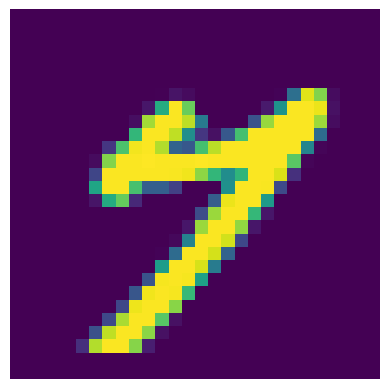

In [112]:
import matplotlib.pyplot as plt

img = x_train[1001].detach().cpu()

img = img.permute(1, 2, 0)

img = img.clamp(0, 1)

plt.imshow(img)
plt.axis("off")
plt.show()

In [113]:
x=x_train[1000].unsqueeze(1)
en.image=x
en.eval()
de.eval()
with torch.no_grad():
    en_latent=en.latent_image(x)
    de.channels=en_latent.shape[1]
    output=de.forward(en_latent)

In [114]:
output.shape

torch.Size([1, 1, 28, 28])

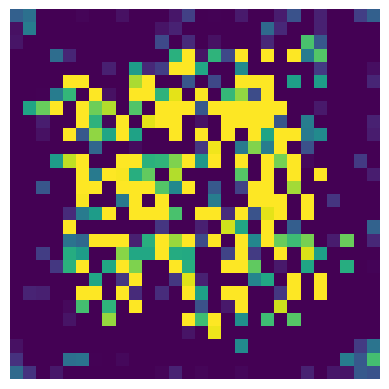

In [115]:
import matplotlib.pyplot as plt

img = output[0].detach().cpu()

img = img.permute(1, 2, 0)

img = img.clamp(0, 1)

plt.imshow(img)
plt.axis("off")
plt.show()

In [116]:
class Cross_attention(nn.Module):
    def __init__(self,embedding,filters):
        super().__init__()
        self.embedding=embedding
        self.filters=filters
        self.WQ=nn.Linear(self.filters,self.filters)
        self.WK=nn.Linear(self.embedding,self.filters)
        self.WV=nn.Linear(self.embedding,self.filters)
    def attention_scores(self,bottleneck,embedded_text):
        samples,filters,row,col=bottleneck.shape
        self.bottleneck1=bottleneck.flatten(2).reshape(samples,filters,row*col).transpose(1,2)
        Q=self.WQ(self.bottleneck1)
        K=self.WK(embedded_text)
        V=self.WV(embedded_text)
        scores=Q@K.transpose(-2,-1)
        scores=scores/(torch.sqrt(torch.tensor(self.filters,dtype=torch.float32)))
        scores=torch.softmax(scores,dim=-1)
        scores=scores@V
        scores=scores.reshape(bottleneck.shape[0],bottleneck.shape[1]
                                                ,bottleneck.shape[2],bottleneck.shape[3])
        scores=scores+bottleneck
        
        return scores
        
        
        

In [117]:
class resblock(nn.Module):
    def __init__(self,channels_in,channels_out,groups,time_dim):
        super().__init__()
        self.channels_in=channels_in
        self.channels_out=channels_out
        self.time_dim=time_dim
        self.resblock_conv1=nn.Conv2d(self.channels_in,self.channels_out,2,stride=1,padding="valid")
        self.time_projection=nn.Linear(self.time_dim,self.resblock_conv1.out_channels)
        num_groups=int(self.resblock_conv1.out_channels/groups)
        self.normalization1=nn.GroupNorm(num_groups=num_groups,num_channels=self.resblock_conv1.out_channels)
        self.activation1=nn.SiLU()
        self.conv2=nn.Conv2d(self.channels_out,self.channels_out,2,stride=1,padding="valid")
    def residual_block(self,noise_zt,time_scheduled_op):
        output_first_conv=self.resblock_conv1(noise_zt)
        et=self.time_projection(time_scheduled_op)
        et=et[:,:,None,None]
        output_first_conv+=et
        normalization=self.normalization1(output_first_conv)
        conv2_op=self.conv2(self.activation1(normalization))
        return conv2_op
        
        

In [118]:
class UNET(nn.Module):
    def __init__(self,image,Time_steps,text,vocab_size,time_dim,embedding_dim,en,de):
        super().__init__()
        self.image=image
        self.Time_steps=Time_steps
        self.text=text
        self.time_dim=time_dim
        self.embedding_dim=embedding_dim
        batch,self.channels,row,col=self.image.shape
        ##ENCODER AND TRINED DECODER
        self.encoder=en
        for p in self.encoder.parameters():
            p.requires_grad = False
        #text encoder
        self.vocab_size=len(tokenizer.word_index)+1
        self.embedded=nn.Embedding(self.vocab_size,self.embedding_dim)
        #Resblock
        self.resblock1=resblock(self.encoder.Sigma_layer[0].out_channels,16,2,16) 
        
        self.norm1=nn.GroupNorm(num_groups=8, num_channels=self.resblock1.resblock_conv1.out_channels)
        self.down1=nn.Conv2d(self.resblock1.resblock_conv1.out_channels,32,2,stride=1)
        self.resblock2=resblock(self.down1.out_channels,32,4,16)
        self.down2=nn.Conv2d(self.resblock2.resblock_conv1.out_channels,34,2,stride=1)
        self.resblock3=nn.Conv2d(self.down2.out_channels,36,4,16) 
        self.act=nn.SiLU()  
        self.norm2=nn.GroupNorm(num_groups=9, num_channels=self.resblock3.out_channels)
        ##Cross Attention
        self.cross_attnxn=Cross_attention(self.embedding_dim,self.resblock3.out_channels)
        self.upsample=nn.ConvTranspose2d(self.cross_attnxn.filters,16,kernel_size=5,stride=1,padding=0)
        self.downsample=nn.Conv2d(self.upsample.out_channels+32,
                                  self.upsample.out_channels,3,stride=1,padding=0)
        self.norm3=nn.GroupNorm(num_groups=4,num_channels=self.upsample.out_channels)
        self.upsample1=nn.ConvTranspose2d(self.downsample.out_channels,16,4,stride=2,padding=0,output_padding=0)
        self.downk_ups_sample1=nn.ConvTranspose2d(self.downsample.out_channels+self.upsample1.out_channels,20,3,stride=1,padding=0)
        self.norm4=nn.GroupNorm(num_groups=5,num_channels=self.downk_ups_sample1.out_channels)
        self.downsample2=nn.Conv2d(self.downk_ups_sample1.out_channels,10,3,stride=1,padding=1)
        self.resblock4=resblock(self.downsample2.out_channels,10,2,16) 
        self.upsample_final=nn.ConvTranspose2d(10,4,kernel_size=3,stride=1,padding=0)
        self.norm5=nn.GroupNorm(num_groups=2,num_channels=self.upsample_final.out_channels)
        ##TRAINED DECODER
        self.trained_Decoder=de
        for p in self.trained_Decoder.parameters():
            p.requires_grad = False
                
    def diffusion_scheduler(self):
        self.beta = torch.linspace(0.0001,0.001,self.Time_steps)
        self.alpha = 1 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha,dim=0)
        return self.beta, self.alpha, self.alpha_bar
    def noise_add(self,batch_size):
        z_latent=self.encoder.latent_image(self.image)
        self.noise_per_timestep=torch.zeros_like(z_latent)
        self.updated_noise_zt=torch.zeros_like(z_latent)
        self.time_tensor=[]
        self.no_of_batches=int(self.image.shape[0]/batch_size)
        for start in range(0,self.image.shape[0],batch_size):
            end=start+batch_size
            z_batch=z_latent[start:end]
            self.time_steps_batch=torch.randint(0,self.Time_steps,(z_batch.shape[0],))
            for i in range(z_batch.shape[0]):
                t=self.time_steps_batch[i]
                alpha_bar_t=self.alpha_bar[t]
                self.noise_per_timestep[start+i]=torch.randn_like(z_batch[i])
                self.updated_noise_zt[start+i]=torch.sqrt(alpha_bar_t)*z_batch[i]+torch.sqrt(1-alpha_bar_t)*self.noise_per_timestep[start+i]
                self.time_tensor.append(t)
        self.time_tensor=torch.stack(self.time_tensor)
        # print(f'shape of time:{self.time_tensor.shape}')
        return self.updated_noise_zt,self.time_tensor
    def text_encoder(self):
        self.encoded_text=self.embedded(self.text)
        return self.encoded_text
    def timestep_embedding(self,t,dim):
        half=dim // 2
        frequencies=torch.exp(-torch.log(torch.tensor(10000.0))*torch.arange(half)/half)
        angles=t[:,None]*frequencies[None,:]
        self.time_scheduled_op=torch.cat([torch.sin(angles), torch.cos(angles)],dim=1)  
        return self.time_scheduled_op
    def resblock(self):
        # noised_zt,time_tensor=self.noise_add(100)
        # self.time_scheduled_op=self.timestep_embedding(self.time_tensor,self.time_dim)
        self.skip1op=self.norm1(self.resblock1.residual_block(self.updated_noise_zt,self.time_scheduled_op))
        self.skip1op=self.act(self.skip1op)
        h1=self.down1(self.skip1op)
        self.skip2op=self.act(self.resblock2.residual_block(h1,self.time_scheduled_op))
        h2=self.down2(self.skip2op)
        self.bottleneck=self.norm2(self.resblock3(h2))
        return self.bottleneck,self.skip1op,self.skip2op,self.time_scheduled_op
    def cross_attention(self):
        attented_scores=self.cross_attnxn.attention_scores(self.bottleneck,self.encoded_text)
        upsampled=self.act(self.upsample(attented_scores))
        
        upsampled_and_skip2=torch.cat([upsampled,self.skip2op],dim=1)
        
        down_sample=self.norm3(self.downsample(upsampled_and_skip2))
        down_sample=self.act(down_sample)
        upsampled1=self.act(self.upsample1(down_sample))
        upsampled1_and_skip1=torch.cat([upsampled1,self.skip1op],dim=1)
        downkernel_upspatial=self.norm4(self.downk_ups_sample1(upsampled1_and_skip1))
        
        downsample_pre=self.act(self.downsample2(downkernel_upspatial))
        
        resblock_output=self.resblock4.residual_block(downsample_pre,self.time_scheduled_op)
        upsampled_final=self.norm5(self.upsample_final(resblock_output))
        
        return upsampled_final
    ##RECHECKING IS NEEDED
    def predict_noise(self,z_t,time_tensor,embedded_text):
        time_scheduled_op = self.timestep_embedding(time_tensor,self.time_dim)
        skip1op = self.resblock1.residual_block(z_t,time_scheduled_op)
        h1=self.down1(skip1op)
        skip2op=self.resblock2.residual_block(h1,time_scheduled_op)
        h2=self.down2(skip2op)
        bottleneck=self.resblock3(h2)
        attended_scores = self.cross_attnxn.attention_scores(bottleneck,embedded_text)
        upsampled = self.upsample(attended_scores)
        upsampled_and_skip2 = torch.cat([upsampled, skip2op],dim=1)
        down_sample = self.downsample(upsampled_and_skip2)
        upsampled1 = self.upsample1(down_sample)
        upsampled1_and_skip1 = torch.cat([upsampled1, skip1op],dim=1)
        downkernel_upspatial = self.downk_ups_sample1(upsampled1_and_skip1)
        downsample_pre=self.downsample2(downkernel_upspatial)
        resblock_output=self.resblock4.residual_block(downsample_pre,time_scheduled_op)
        
        predicted_noise=self.upsample_final(resblock_output)
        return predicted_noise
    def reverse_step(self, z_t, predicted_noise, t):
        beta_t = self.beta[t]
        alpha_t = self.alpha[t]
        alpha_bar_t = self.alpha_bar[t]
        mean=(1/torch.sqrt(alpha_t))*(z_t-((1-alpha_t)/torch.sqrt(1-alpha_bar_t))*predicted_noise)
        if t>0:
            noise=torch.randn_like(z_t)
            z_previous=(mean+torch.sqrt(beta_t) * noise)
        else:
            z_previous=mean
        return z_previous
    def image_gen(self,z):
        with torch.no_grad():
            x=self.trained_Decoder.forward(z)
        return x
    def new_generation(self,zt,embedded_text,time):
        with torch.no_grad():
            for t in reversed(range(time+1)):
                time_tensor=torch.tensor([t])
                predicted_noise=self.predict_noise(zt,time_tensor,embedded_text)
                zt=self.reverse_step(zt,predicted_noise,t)
            return zt
    def forward(self, batch_size):
        self.diffusion_scheduler()
        self.noise_add(batch_size)
        self.timestep_embedding(self.time_tensor,self.time_dim)
        self.text_encoder()
        self.resblock()
        predicted_noise = self.cross_attention()
        return predicted_noise
            
        
        









        
        

In [119]:
# def __init__(self,image,Time_steps,text,vocab_size,embedding_dim,time_dim,num_classes,channels_res_out):
#     def __init__(self,image,Time_steps,text,vocab_size,time_dim,embedding_dim):


In [120]:
unet=UNET(x_test,100,output_seq_pad,len(tokenizer.word_index)+1,16,64,en,de)

In [121]:
predicted_noise=unet.forward(50)

In [122]:
optimizer = torch.optim.Adam(
    unet.parameters(),
    lr=0.0001
)
loss_fn=nn.MSELoss()

In [123]:
unet.train()
for epoch in range(100):
    optimizer.zero_grad()
    predicted_noise = unet.forward(50)
    actual_noise = unet.noise_per_timestep
    loss = loss_fn(predicted_noise,actual_noise)
    # print("actual:", actual_noise.mean().item(), actual_noise.std().item())
    # print("predicted:", predicted_noise.mean().item(), predicted_noise.std().item())
    loss.backward()
    optimizer.step()
    if epoch%10==0:
        print(f"Epoch [{epoch+1}/50], Loss: {loss.item():.4f}")

Epoch [1/50], Loss: 1.9937
Epoch [11/50], Loss: 1.9743
Epoch [21/50], Loss: 1.9606
Epoch [31/50], Loss: 1.9582
Epoch [41/50], Loss: 1.9483
Epoch [51/50], Loss: 1.9272
Epoch [61/50], Loss: 1.9231
Epoch [71/50], Loss: 1.9140
Epoch [81/50], Loss: 1.9087
Epoch [91/50], Loss: 1.9037


In [124]:
unet.eval()
with torch.no_grad():
    z_t = torch.randn_like(en.z_latent[:4])
    embedded_text = unet.text_encoder()[:4]
    z=unet.new_generation(z_t,embedded_text,99)
    img=unet.image_gen(z)

In [125]:
img.shape

torch.Size([4, 1, 28, 28])

torch.Size([1, 28, 28])


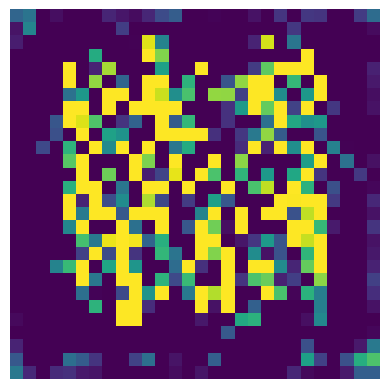

torch.Size([1, 28, 28])


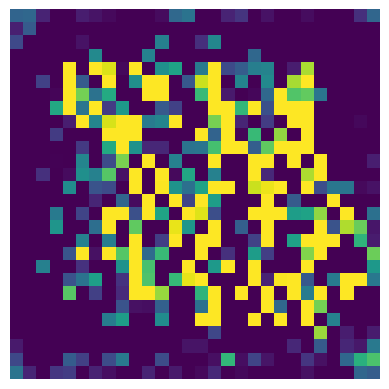

torch.Size([1, 28, 28])


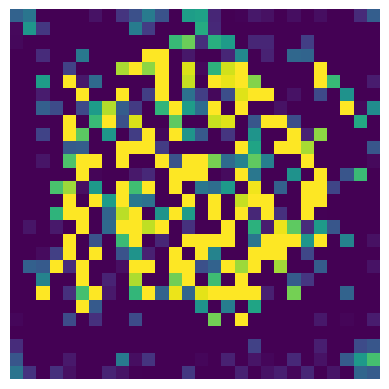

torch.Size([1, 28, 28])


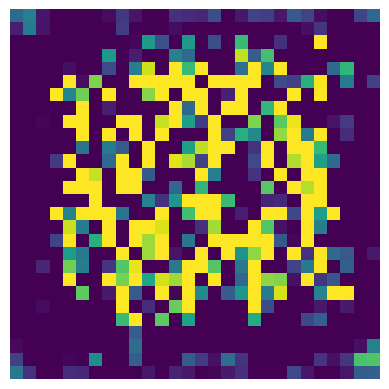

In [126]:
import matplotlib.pyplot as plt

for i in range(img.shape[0]):

    imgs = img[i].detach().cpu()

    print(imgs.shape)

    imgs = imgs.permute(1, 2, 0)

    imgs = imgs.clamp(0, 1)

    plt.imshow(imgs)
    plt.axis("off")
    plt.show()

In [127]:
print(unet.encoder is en)

True


In [128]:
print(
    torch.equal(
        unet.encoder.layer1[0].weight,
        en.layer1[0].weight
    )
)

True


In [129]:
for name, p in unet.encoder.named_parameters():
    print(name, p.requires_grad)

layer1.0.weight False
layer1.0.bias False
layer1.2.weight False
layer1.2.bias False
layer2.0.weight False
layer2.0.bias False
norm1.weight False
norm1.bias False
mu_layer.0.weight False
mu_layer.0.bias False
Sigma_layer.0.weight False
Sigma_layer.0.bias False


In [130]:
unet.encoder.named_parameters()

<generator object Module.named_parameters at 0x000002CCB24BBE40>

In [131]:
print(unet.encoder.training)

False
